# ARCADIA Spatial Parameter Sensitivity

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

In [2]:
import zipfile, io

ZIP_PATH = Path("spatial_sensitivity_tables_csv.zip")
with zipfile.ZipFile(ZIP_PATH) as z:
    graph_df = pd.read_csv(io.TextIOWrapper(z.open("spatial_graph_statistics.csv")))

# ── Tidy the graph statistics ─────────────────────────────────────────────────
graph_df = graph_df.copy()
graph_df["pct_num"] = graph_df["Percentile"].str.extract(r"(\d+)").astype(int)
for col in ["Edges Pruned", "Cells Affected"]:
    graph_df[col] = graph_df[col].astype(str).str.replace(",", "").astype(float)
for col in ["% Edges Pruned", "% Cells Affected"]:
    graph_df[col] = graph_df[col].astype(str).str.replace("%", "").astype(float)

In [3]:
# ── Hardcoded multi-seed statistics ──────────────────────────────────────────
# Source: paper Table 1 (ARCADIA) and sensitivity_300ep_3.md §3.1, n=10 runs per config.
# std = np.nan where only a single point value was reported (MaxFuse, scMODAL).
PAPER_STATS = {
    "ARCADIA": {
        "kSep":             {"mean": 0.510, "std": 0.016},
        "Cell-type F1":     {"mean": 0.897, "std": 0.003},
        "ARI Score":        {"mean": 0.791, "std": 0.011},
        "iLISI":            {"mean": 1.543, "std": 0.038},
        "Silhouette Score": {"mean": 0.315, "std": 0.017},
    },
    "MaxFuse": {
        "kSep":             {"mean": 0.212,  "std": np.nan},
        "Cell-type F1":     {"mean": 0.888,  "std": np.nan},
        "ARI Score":        {"mean": 0.680,  "std": np.nan},
        "iLISI":            {"mean": 1.208,  "std": np.nan},
        "Silhouette Score": {"mean": 0.061,  "std": np.nan},
    },
    "scMODAL": {
        "kSep":             {"mean": 0.449,  "std": np.nan},
        "Cell-type F1":     {"mean": 0.848,  "std": np.nan},
        "ARI Score":        {"mean": 0.635,  "std": np.nan},
        "iLISI":            {"mean": 1.690,  "std": np.nan},
        "Silhouette Score": {"mean": 0.159,  "std": np.nan},
    },
}

SWEEP_STATS = {
    "pct80_k15":  {"Cell-type F1": {"mean": 0.926, "std": 0.019},
                   "Silhouette Score": {"mean": 0.279, "std": 0.041},
                   "ARI Score":        {"mean": 0.830, "std": 0.041},
                   "iLISI":            {"mean": 1.491, "std": 0.121}},
    "pct100_k15": {"Cell-type F1": {"mean": 0.917, "std": 0.018},
                   "Silhouette Score": {"mean": 0.269, "std": 0.038},
                   "ARI Score":        {"mean": 0.812, "std": 0.036},
                   "iLISI":            {"mean": 1.476, "std": 0.123}},
    "pct95_k10":  {"Cell-type F1": {"mean": 0.916, "std": 0.016},
                   "Silhouette Score": {"mean": 0.271, "std": 0.037},
                   "ARI Score":        {"mean": 0.811, "std": 0.034},
                   "iLISI":            {"mean": 1.484, "std": 0.107}},
    "pct95_k30":  {"Cell-type F1": {"mean": 0.924, "std": 0.015},
                   "Silhouette Score": {"mean": 0.279, "std": 0.040},
                   "ARI Score":        {"mean": 0.826, "std": 0.032},
                   "iLISI":            {"mean": 1.502, "std": 0.143}},
}

METRICS = ["Cell-type F1", "Silhouette Score", "ARI Score", "iLISI"]
METRIC_LABELS = {
    "Cell-type F1":     "Cell-type F1",
    "Silhouette Score": "Silhouette Score",
    "ARI Score":        "ARI Score",
    "iLISI":            "iLISI",
}

# ── Build pct_df directly from hardcoded stats ────────────────────────────────
_arc = PAPER_STATS["ARCADIA"]
_pct_rows = []
for pct_num, key in [(80, "pct80_k15"), (95, None), (100, "pct100_k15")]:
    src = _arc if key is None else SWEEP_STATS[key]
    row = {"Percentile": f"pct{pct_num}", "pct_num": pct_num}
    for col in METRICS:
        row[col] = src[col]["mean"]
        row[f"{col}_std"] = src[col]["std"]
    _pct_rows.append(row)
pct_df = pd.DataFrame(_pct_rows)

# ── Build k_df directly from hardcoded stats ──────────────────────────────────
_k_rows = []
for k_num, key in [(10, "pct95_k10"), (15, None), (30, "pct95_k30")]:
    src = _arc if key is None else SWEEP_STATS[key]
    row = {"k": f"k{k_num}", "k_num": k_num}
    for col in METRICS:
        row[col] = src[col]["mean"]
        row[f"{col}_std"] = src[col]["std"]
    _k_rows.append(row)
k_df = pd.DataFrame(_k_rows)

# ── Build full_df directly from hardcoded stats ───────────────────────────────
_full_configs = [
    ("Baseline (pct95, k15)", None),
    ("pct80, k15",            "pct80_k15"),
    ("pct100, k15",           "pct100_k15"),
    ("pct95, k10",            "pct95_k10"),
    ("pct95, k30",            "pct95_k30"),
]
_full_rows = []
for _name, _key in _full_configs:
    src = _arc if _key is None else SWEEP_STATS[_key]
    row = {"Configuration": _name}
    for col in METRICS:
        row[col] = src[col]["mean"]
        row[f"{col}_std"] = src[col]["std"]
    _full_rows.append(row)
full_df = pd.DataFrame(_full_rows)

# ── Long-format paper comparison DataFrame ────────────────────────────────────
paper_df = pd.DataFrame(
    [
        {"Method": method, "Metric": metric, "mean": vals["mean"], "std": vals["std"]}
        for method, metrics in PAPER_STATS.items()
        for metric, vals in metrics.items()
    ]
)

METHOD_ORDER  = ["ARCADIA", "MaxFuse", "scMODAL"]
METHOD_COLORS = {"ARCADIA": "#e15759", "MaxFuse": "#4e79a7", "scMODAL": "#59a14f"}

# ── Derive BENCHMARKS (MaxFuse + scMODAL reference lines) ─────────────────────
BENCHMARKS = {
    metric: {
        method: PAPER_STATS[method][metric]["mean"]
        for method in ["MaxFuse", "scMODAL"]
        if not np.isnan(PAPER_STATS[method][metric]["mean"])
    }
    for metric in METRICS
}

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.15)
PALETTE = ['black', 'black', 'black', 'black']
BASELINE_STYLE = dict(color="#888888", linestyle="--", linewidth=1.2, alpha=0.8)
REF_STYLES = {
    "MaxFuse": dict(color="#4e79a7", linestyle=":",  linewidth=1.4, alpha=0.9),
    "scMODAL": dict(color="#59a14f", linestyle="-.", linewidth=1.4, alpha=0.9),
}

FIG_DIR = Path("fig")
FIG_DIR.mkdir(exist_ok=True)

print("Data ready.")

Data ready.


## Figure — Spatial Graph Statistics vs. Percentile Threshold

Shows the structural impact of the pruning parameter (how aggressively edges and cells are affected).

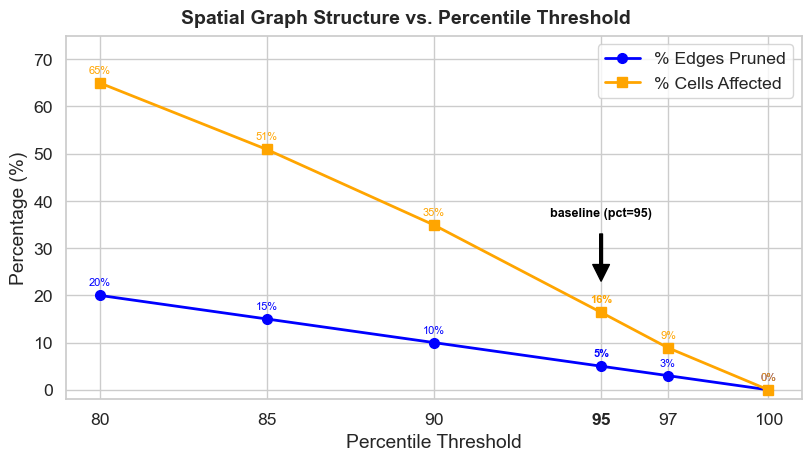

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
fig.suptitle(
    "Spatial Graph Structure vs. Percentile Threshold",
    fontsize=14, fontweight="bold"
)

x_g = graph_df["pct_num"].values
c_edges = 'blue'
c_cells = 'orange'

l1, = ax.plot(x_g, graph_df["% Edges Pruned"].values,
              color=c_edges, marker="o", markersize=7, linewidth=2, label="% Edges Pruned")
l2, = ax.plot(x_g, graph_df["% Cells Affected"].values,
              color=c_cells, marker="s", markersize=7, linewidth=2, label="% Cells Affected")

# Indicate the baseline index (pct=95) for bolding
baseline_idx = list(x_g).index(95) if 95 in x_g else None

for i, (xi, ye, yc) in enumerate(zip(x_g,
                                     graph_df["% Edges Pruned"].values,
                                     graph_df["% Cells Affected"].values)):
    # Bolding the baseline
    fontweight = "bold" if (baseline_idx is not None and i == baseline_idx) else "normal"
    ax.annotate(f"{ye:.0f}%", xy=(xi, ye), xytext=(0, 7),
                textcoords="offset points", ha="center", fontsize=8, color=c_edges, fontweight=fontweight)
    ax.annotate(f"{yc:.0f}%", xy=(xi, yc), xytext=(0, 7),
                textcoords="offset points", ha="center", fontsize=8, color=c_cells, fontweight=fontweight)

# Draw a vertical downward facing black arrow at x=95, y~23%
arrow_x = 95
arrow_y = 23  # This is approximate, adjust as needed for your data
arrow_head_length = 10  # The length the arrow will cover downward
ax.annotate(
    '', 
    xy=(arrow_x, arrow_y), 
    xytext=(arrow_x, arrow_y + arrow_head_length),
    arrowprops=dict(facecolor='black', edgecolor='black', width=2, headwidth=12, headlength=12)
)
# Optionally, add a label
ax.text(arrow_x, arrow_y + arrow_head_length + 3, "baseline (pct=95)", 
        ha='center', va='bottom', fontsize=9, color="black", fontweight="bold")

ax.set_xlabel("Percentile Threshold")
ax.set_ylabel("Percentage (%)")
ax.set_xticks(x_g)

# Emphasize the baseline (95) xtick by bolding its label fontweight
for label, val in zip(ax.get_xticklabels(), x_g):
    if val == 95:
        label.set_fontweight("bold")
ax.set_ylim(-2, 75)
ax.legend()

# plt.savefig(FIG_DIR / "graph_statistics_plot.pdf", bbox_inches="tight")
# plt.savefig(FIG_DIR / "graph_statistics_plot.png", bbox_inches="tight", dpi=150)
plt.show()
# print("Saved: graph_statistics_plot.pdf / .png")

## Figure — All Configurations: Full Results Overview

Horizontal bar chart across all 5 tested configurations for quick comparison.

In [5]:
df_labels = ['Baseline (pct95, 15-nn)',
 'pct80, 15-nn',
 'pct100, 15-nn',
 'pct95, 10-nn',
 'pct95, 30-nn']
full_df['Configuration'] = df_labels

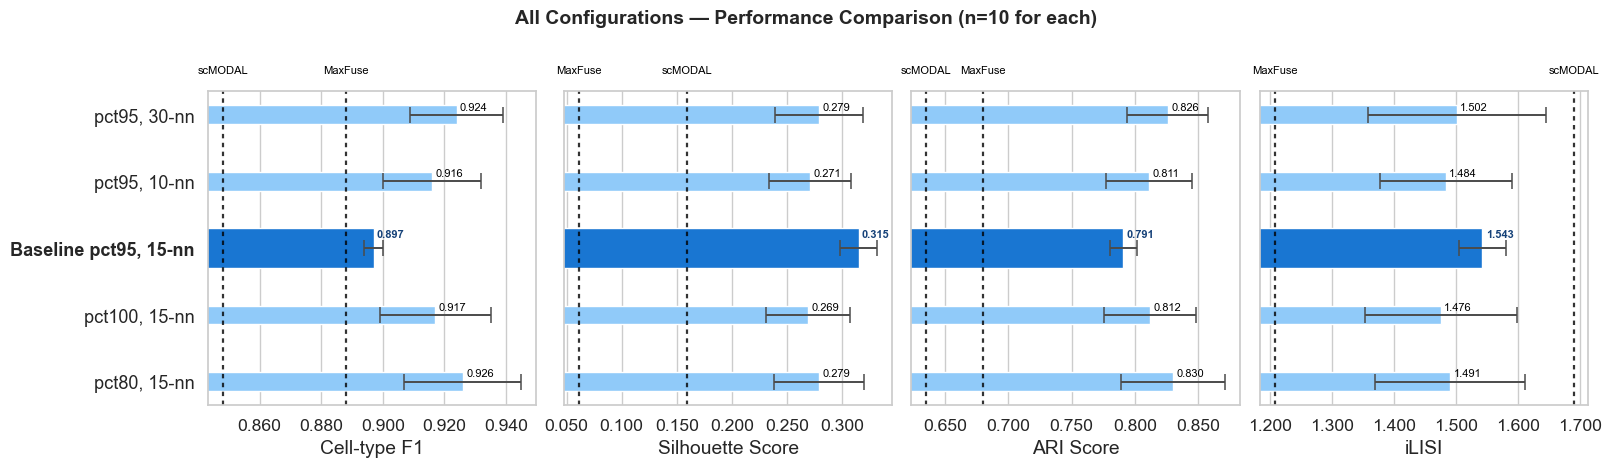

In [6]:
# Flag to include Arcadia reference lines; set to False to exclude Arcadia for fair method-only comparison
INCLUDE_PAPER_REFS = True

# Flag to set xlim automatically regardless of manual limits above
AUTO_SET_XLIMS = True  # Set to True to make xlims always automatic, False to use METRIC_XLIMS if available

# Clean up the full results table
full = full_df.copy()
full["Config"] = full["Configuration"].str.replace(r"[\(\)]", "", regex=True)

# Reorder so the baseline row is in the middle (third row, index 2)
baseline_rows = full[full["Configuration"].str.contains("Baseline", case=False)]
non_baseline = full[~full["Configuration"].str.contains("Baseline", case=False)]
# If only one baseline row, move it to the third row (index 2)
if len(baseline_rows) == 1 and len(full) >= 3:
    # reset index for concat
    non_baseline = non_baseline.reset_index(drop=True)
    baseline_row = baseline_rows.iloc[0]
    # Insert at position 2
    top = non_baseline.iloc[:2]
    bottom = non_baseline.iloc[2:]
    full = pd.concat([top, pd.DataFrame([baseline_row]), bottom], ignore_index=True)
else:
    full = pd.concat([baseline_rows, non_baseline], ignore_index=True)  # fallback

BASELINE_COLOR = "#1976d2"      # strong blue
NON_BASELINE_COLOR = "#90caf9"  # light blue

# xlim ranges for each metric
METRIC_XLIMS = {
    "Match Acc": [0.8, 0.9],
    "Sil Score": [0, 0.8],
    "ARI Score": [0.6, 0.64],
    "iLISI": [1.0, 1.8],
}

# Only use the correct column formatting for std columns
metric_std_cols = {}
for m in METRICS:
    std_col = f"{m}_std"
    if std_col in full.columns:
        metric_std_cols[m] = std_col

# Setup for sharing the y-axis
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True, constrained_layout=True)

# --- Title will be set *after* reference line labels for better stacking ---
fig_title = "All Configurations — Performance Comparison (n=10 for each)"

is_baseline = full["Configuration"].str.contains("Baseline", case=False)

# We'll get the common y-tick labels from the first axis after plotting.
for i_ax, (ax, metric) in enumerate(zip(axes, METRICS)):
    vals = full[metric].values.astype(float)
    # Prepare error bars (std), default to None
    std = None
    if metric in metric_std_cols:
        std_col = metric_std_cols[metric]
        std = full[std_col].values
        import numpy as np
        std = np.array([x if x is not None and not (isinstance(x, float) and np.isnan(x)) else 0.0 for x in std], dtype=float)

    bar_heights = [0.6 if baseline else 0.38 for baseline in is_baseline]
    y_pos = list(range(len(full)))
    bars = []
    bar_centers = []
    for i, (y, v, base) in enumerate(zip(y_pos, vals, is_baseline)):
        color = BASELINE_COLOR if base else NON_BASELINE_COLOR
        height = 0.6 if base else 0.28
        b = ax.barh([full["Config"].iloc[i]], [v], color=color, edgecolor="white", height=height)
        bars.append(b[0])
        bar_centers.append(b[0].get_y() + b[0].get_height() / 2)

    # Add error bars for configs that have std > 0
    if std is not None:
        err_configs = []
        err_vals = []
        err_stds = []
        err_ys = []
        for i, s in enumerate(std):
            if s > 0:
                err_configs.append(full["Config"].iloc[i])
                err_vals.append(vals[i])
                err_stds.append(s)
                err_ys.append(bar_centers[i])
        if len(err_configs) > 0:
            ax.errorbar(
                x=err_vals,
                y=err_ys,
                xerr=err_stds,
                fmt="none",
                ecolor="#4b4b4b",
                elinewidth=1.4,
                capsize=6,
                capthick=1.1,
                zorder=15
            )

    # Reference lines for each metric
    if INCLUDE_PAPER_REFS:
        references = BENCHMARKS.get(metric, {})
        filtered_references = references.copy()
        line_handles = []
        for ref_method, refval in filtered_references.items():
            hline = ax.axvline(
                refval, linestyle=(0, (2, 2)), color="black", lw=1.6, alpha=0.8, zorder=1
            )
            line_handles.append((hline, ref_method, refval))
    else:
        filtered_references = {}
        line_handles = []

    # Place all reference labels slightly lower so there is no weird spacing
    ax_xmin, ax_xmax = ax.get_xlim() if metric in METRIC_XLIMS else (vals.min(), vals.max())
    axes_bbox = ax.get_position()
    ax_height = axes_bbox.height
    ylim = ax.get_ylim()
    # LOWERED: place at 1.05 in axis fraction instead of 1.10
    label_y_fraction = 1.05
    for hline, ref_method, refval in line_handles:
        if ref_method.lower() == "scmodal":
            label_txt = "scMODAL"
        else:
            label_txt = ref_method
        trans = ax.get_xaxis_transform()
        ax.text(
            refval,
            label_y_fraction,  # a bit above the top of the axis, but not too far
            f'{label_txt}',
            ha='center', va='bottom', fontsize=8, color='black',
            bbox=dict(boxstyle="round,pad=0.14", lw=0, fc="white", alpha=0.82),
            transform=trans, clip_on=False, zorder=20
        )

    # No subplot titles per instruction; label only with x-axis label below
    # ax.set_title(METRIC_LABELS[metric], fontweight="semibold", fontsize=10, pad=33)

    ax.grid(False, axis="y")

    # Set xlim either automatically or manually based on AUTO_SET_XLIMS flag
    if AUTO_SET_XLIMS:
        xmin = vals.min()
        xmax = vals.max()
        if len(filtered_references) > 0:
            refmin = min(filtered_references.values())
            refmax = max(filtered_references.values())
            xmin = min(xmin, refmin)
            xmax = max(xmax, refmax)
        if std is not None and len(std) > 0:
            if (std > 0).any():
                xmin = min(xmin, (vals - std).min())
                xmax = max(xmax, (vals + std).max())
        center = (xmin + xmax) / 2.
        span = xmax - xmin if xmax > xmin else 1.0
        pad = span * 0.05 if span > 0 else 0.02
        ax.set_xlim(xmin - pad, xmax + pad)
        xmin_plot, xmax_plot = ax.get_xlim()
    else:
        xlim = METRIC_XLIMS.get(metric, None)
        if xlim is not None:
            ax.set_xlim(xlim)
            xmin_plot, xmax_plot = xlim
        else:
            xmin_plot = vals.min() * 0.995
            xmax_plot = vals.max() * 1.005
            for refval in filtered_references.values():
                xmin_plot = min(xmin_plot, refval * 0.98)
                xmax_plot = max(xmax_plot, refval * 1.02)
            if std is not None and len(std) > 0:
                if (std > 0).any():
                    xmin_plot = min(xmin_plot, (vals - std).min())
                    xmax_plot = max(xmax_plot, (vals + std).max())
            ax.set_xlim(xmin_plot, xmax_plot)

    ax.set_xlabel(metric)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.tick_params(axis="y", labelsize=12)  # <- Larger y-tick font size

    # Only put y-axis label positioning on the first subplot
    if i_ax == 0:
        ax.yaxis.set_label_coords(-0.04, 1.075)
    else:
        ax.set_ylabel("")

    # Move the value label for all bars (baseline and alternatives) a bit higher if there is an error bar,
    # so the label does not intersect with the error bar.
    for idx, (bar, val, base) in enumerate(zip(bars, vals, is_baseline)):
        bar_height = bar.get_height()
        if std is not None and std[idx] > 0:
            offset = 0.23 * bar_height if base else 0.16 * bar_height  # slightly smaller offset for alternatives
            va_str = "bottom"
        else:
            offset = 0.15 * bar_height if base else 0.10 * bar_height
            va_str = "center"
        ax.text(
            bar.get_width() + (xmax_plot - xmin_plot) * 0.01,
            bar.get_y() + bar_height/2 + offset,
            f"{val:.3f}",
            va=va_str if (std is not None and std[idx] > 0) else "center",
            fontsize=8,
            fontweight="bold" if base else "normal",
            color="#164279" if base else "black"
        )

    yticks = ax.get_yticklabels()
    for i, label in enumerate(yticks):
        label.set_fontsize(13)
        if is_baseline.iloc[i]:
            label.set_fontweight("bold")

# After all subplots, set the figure-level title so it sits on top (above reference labels)
fig.suptitle(
    fig_title,
    fontsize=14, fontweight="bold", y=1.13  # Lowered a bit to fit better above new label positions
)

# plt.savefig(FIG_DIR / "all_configs_comparison.pdf", bbox_inches="tight")
# plt.savefig(FIG_DIR / "all_configs_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
# print("Saved: all_configs_comparison.pdf / .png")